In [1]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
#from matplotlib import colormaps
#import math

In [2]:
df = pd.read_csv("buena2.txt", delimiter="\t", skiprows=1, decimal=",")
IA = df["IA/nA"].to_numpy()
U1 = df["U1/V"].to_numpy()

In [3]:
def sample_to_voltage(x):
    return x*(max(U1)-min(U1))/len(U1) + min(U1)

sampleSize = (max(U1)-min(U1))/len(U1)

In [4]:
peakIndex, peakData = scipy.signal.find_peaks(IA, prominence=0.2, distance=50)
#peakError = U1[peaks[1].get("right_bases")] - U1[peaks[1].get("left_bases")]

peakWidths, peakWidthHeights, peakLeftIps, peakRightIps = scipy.signal.peak_widths(IA, peakIndex, rel_height=0.05)

valleyIndex, valleyData = scipy.signal.find_peaks(-IA, prominence = 0.2, distance = 50)

valleyWidths, valleyWidthHeights, valleyLeftIps, valleyRightIps = scipy.signal.peak_widths(-IA, valleyIndex, rel_height=0.05)


In [5]:
peakVoltages = U1[peakIndex]
valleyVoltages = U1[valleyIndex]

peakErrors = peakWidths*sampleSize/2
valleyErrors = valleyWidths*sampleSize/2

peakIntensities = IA[peakIndex]
valleyIntensities = IA[valleyIndex]


print(peakIntensities)
print(peakVoltages)
print(peakErrors)

print(valleyIntensities)
print(valleyVoltages)
print(valleyErrors)

[ 1.22  4.45 10.7  18.71]
[13.04 28.91 46.66 65.1 ]
[0.9349981  2.27097123 1.33017517 1.07160629]
[ 0.06  0.14  3.77 13.56]
[16.87 34.43 53.28 72.45]
[0.57003148 0.62312863 0.96612402 1.0090493 ]


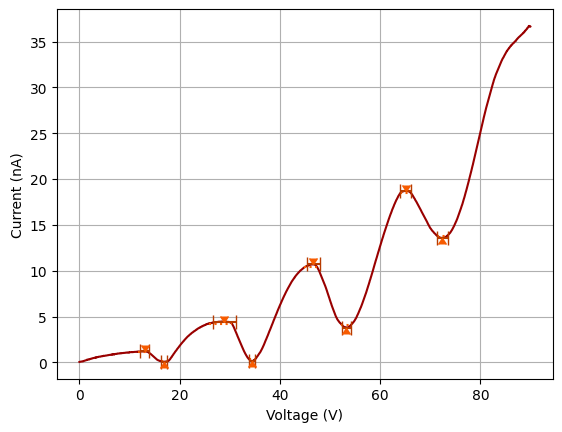

In [6]:
plt.plot(U1, IA, color = "#990000")
plt.errorbar(peakVoltages, peakIntensities, marker = 7, color = "#f75b00", xerr = peakErrors, capsize= 5, zorder = 10, ls = "", ecolor = "#b73b00")
plt.errorbar(valleyVoltages, valleyIntensities, marker = 6, color = "#f75b00", xerr = valleyErrors, capsize = 5, zorder = 10, ls = "", ecolor = "#b73b00")

plt.hlines(peakWidthHeights, sample_to_voltage(peakLeftIps), sample_to_voltage(peakRightIps), color = "#f75b00", ls = ":")
plt.hlines(-valleyWidthHeights, sample_to_voltage(valleyLeftIps), sample_to_voltage(valleyRightIps), color = "#f75b00", ls = ":")

plt.xlabel("Voltage (V)")
plt.ylabel("Current (nA)")

plt.grid()

plt.savefig("plotFranckHertz.png", dpi = 300)

plt.show()